<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/55_end_to_end_machine_learning_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# End-to-End Machine Learning Workflow

In this notebook, we build a complete machine learning workflow from data generation to model deployment readiness.

The workflow includes:

- Dataset Creation
- Data Exploration
- Train-Test Split
- Feature Scaling
- Model Training
- Model Evaluation
- Model Persistence
- Loading Saved Model
- Predicting New Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib

In [2]:
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    random_state=42
)

print("Feature Shape:", X.shape)

Feature Shape: (1000, 10)


In [3]:
feature_names = [
    f"Feature_{i}"
    for i in range(1,11)
]

df = pd.DataFrame(
    X,
    columns=feature_names
)

df["Target"] = y

df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,-1.030931,1.391626,0.547274,0.928932,-1.738880,1.250002,1.332551,1.578256,2.124722,-0.318434,0
1,-2.766254,1.247870,-0.303691,1.083145,0.710836,1.968202,-1.794192,2.346422,1.700778,-0.001190,1
2,-0.558987,0.299849,1.527071,0.360442,-1.360209,1.100793,-0.755951,1.331933,2.041105,-0.824404,0
3,-1.350289,-2.046078,-0.614264,0.126459,-0.783923,5.895026,-0.915477,-3.184768,-0.399260,-3.920960,0
4,-0.275754,-0.728495,0.027727,-0.660834,-1.928161,3.544945,1.446944,-1.111662,0.313766,-2.376528,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Feature_1   1000 non-null   float64
 1   Feature_2   1000 non-null   float64
 2   Feature_3   1000 non-null   float64
 3   Feature_4   1000 non-null   float64
 4   Feature_5   1000 non-null   float64
 5   Feature_6   1000 non-null   float64
 6   Feature_7   1000 non-null   float64
 7   Feature_8   1000 non-null   float64
 8   Feature_9   1000 non-null   float64
 9   Feature_10  1000 non-null   float64
 10  Target      1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB


In [5]:
df["Target"].value_counts()

,count
Target,
1,502
0,498


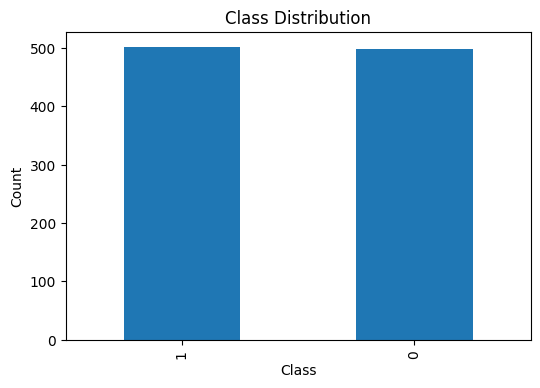

In [6]:
plt.figure(figsize=(6,4))

df["Target"].value_counts().plot(
    kind="bar"
)

plt.title("Class Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

In [7]:
X = df.drop(
    "Target",
    axis=1
)

y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [9]:
model = RandomForestClassifier(
    random_state=42
)

model.fit(
    X_train_scaled,
    y_train
)

RandomForestClassifier(random_state=42)

In [10]:
predictions = model.predict(
    X_test_scaled
)

In [11]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "Accuracy:",
    round(accuracy,4)
)

Accuracy: 0.855


In [12]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.93      0.81      0.86       113
           1       0.78      0.92      0.85        87

    accuracy                           0.85       200
   macro avg       0.86      0.86      0.85       200
weighted avg       0.87      0.85      0.86       200



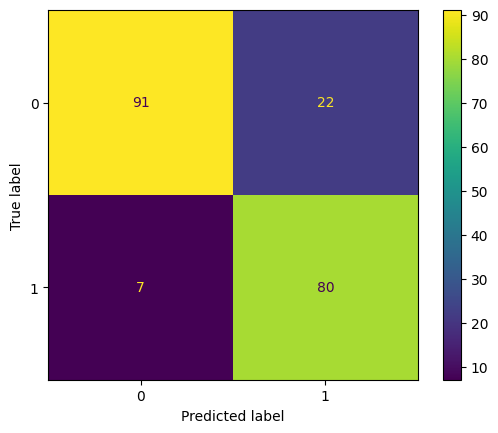

In [13]:
cm = confusion_matrix(
    y_test,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [14]:
importance = pd.DataFrame({

    "Feature":feature_names,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,Feature_6,0.316342
9,Feature_10,0.215464
7,Feature_8,0.091557
2,Feature_3,0.072384
1,Feature_2,0.072018
0,Feature_1,0.069975
4,Feature_5,0.056390
8,Feature_9,0.052728
3,Feature_4,0.027688
6,Feature_7,0.025453


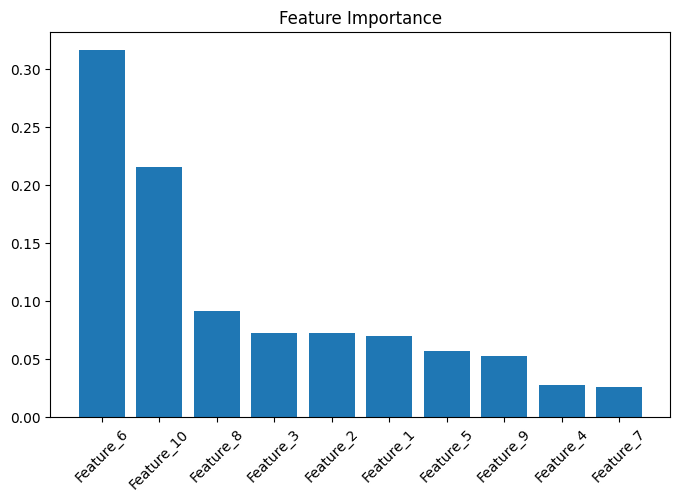

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title(
    "Feature Importance"
)

plt.show()

In [16]:
joblib.dump(
    model,
    "rf_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Model Saved")

Model Saved


In [17]:
loaded_model = joblib.load(
    "rf_model.pkl"
)

loaded_scaler = joblib.load(
    "scaler.pkl"
)

print("Model Loaded")

Model Loaded


In [18]:
new_sample = X.iloc[[0]]

new_sample_scaled = loaded_scaler.transform(
    new_sample
)

prediction = loaded_model.predict(
    new_sample_scaled
)

probability = loaded_model.predict_proba(
    new_sample_scaled
)

print(
    "Predicted Class:",
    prediction[0]
)

print(
    "Prediction Probability:"
)

print(probability)

Predicted Class: 0
Prediction Probability:
[[0.9 0.1]]


In [19]:
loaded_predictions = loaded_model.predict(
    X_test_scaled
)

print(
    "Predictions Match:",
    np.array_equal(
        predictions,
        loaded_predictions
    )
)

Predictions Match: True


In [20]:
summary = pd.DataFrame({

    "Step":[
        "Dataset Created",
        "Train-Test Split",
        "Feature Scaling",
        "Model Training",
        "Evaluation",
        "Model Saved",
        "Model Loaded",
        "Prediction"
    ],

    "Status":[
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed",
        "Completed"
    ]

})

summary

,Step,Status
0,Dataset Created,Completed
1,Train-Test Split,Completed
2,Feature Scaling,Completed
3,Model Training,Completed
4,Evaluation,Completed
5,Model Saved,Completed
6,Model Loaded,Completed
7,Prediction,Completed


## Conclusion

This notebook demonstrated a complete end-to-end Machine Learning workflow.

### Workflow Summary

- Created and explored a classification dataset.
- Split the data into training and testing sets.
- Applied feature scaling using StandardScaler.
- Trained a Random Forest classifier.
- Evaluated model performance using accuracy, confusion matrix, and classification report.
- Analyzed feature importance.
- Saved the trained model and scaler using Joblib.
- Loaded the saved artifacts and successfully predicted unseen data.

This notebook integrates multiple concepts learned throughout the Machine Learning Foundations section into a single practical workflow.